# 🍷 01 — Exploratory Data Analysis (EDA)

## Vad är EDA och varför börjar vi här?

Innan vi bygger något som helst — ingen modell, ingen preprocessing, inget träning — måste vi
**förstå vårt data**. Det är precis vad EDA handlar om.

Tänk på det som att vara en ny läkare som träffar en patient för första gången: du tar blodtryck,
lyssnar på hjärtat och tittar på journalen *innan* du skriver ut medicin. Att hoppa direkt till
modellbygge utan EDA är som att skriva ut recept i blindo.

### Vad vi undersöker i denna notebook

| Avsnitt | Fråga vi svarar på |
|---|---|
| 1. Imports & konfiguration | Har vi rätt verktyg på plats? |
| 2. Ladda rådata | Hur ser datasetet ut på ytan? |
| 3. Datakvalitet | Saknas värden? Finns dubbletter? Rätt datatyper? |
| 4. Klassfördelning | Är target-variabeln balanserad eller skev? |
| 5. Numeriska features | Hur är varje feature fördelad? Skiljer sig klass 0 och 1 åt? |
| 6. Korrelationsmatris | Samvarierar features med varandra eller med target? |
| 7. Features vs target | Boxplots — vilka features separerar klasserna bäst? |
| 8. Sammanfattning | Vad tar vi med oss in i modelleringen? |

### Datasetet i korthet

**WineQT.csv** är en kombinerad version av UCI Wine Quality-datasetet (röd + vit vin).
Varje rad är ett vinprov med 11 fysikalisk-kemiska mätningar som features, plus en
`quality`-poäng (3–9) som vi omvandlar till en binär label:

- **1 = Bra vin** → `quality ≥ 6`
- **0 = Dåligt vin** → `quality < 6`

---

## Cell 1 — Imports & konfiguration

Vi importerar alla bibliotek vi kommer att använda genom hela notebooken och sätter
globala inställningar för plottar. Att samla alla imports i en cell längst upp är god praxis —
det gör beroenden tydliga och gör det enkelt att felsöka om något saknas i miljön.

Vi lägger också till `src/` i Python-sökvägen så att vi kan importera våra egna moduler
direkt, precis som ett installerat paket.

In [1]:
# ── Sökväg: lägg till src/ så att egna moduler är importerbara ───────────────
import sys
import os

sys.path.append(os.path.join(os.path.dirname("__file__"), "..", "src"))

# ── Standardbibliotek ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")          # tysta icke-kritiska varningar

# ── Data & numerik ─────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisering ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Globala plott-inställningar ────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi"      : 120,
    "figure.facecolor": "white",
    "axes.spines.top" : False,
    "axes.spines.right": False,
})

# ── Paths (CAPS = konstant) ────────────────────────────────────────────────────
DATA_RAW  = os.path.join("..", "data", "raw",  "WineQT.csv")
FIG_DIR   = os.path.join("..", "reports", "figures")
os.makedirs(FIG_DIR, exist_ok=True)        # skapa mappen om den inte finns

# ── Bekräftelse ────────────────────────────────────────────────────────────────
print("✅ Imports klara")
print(f"   NumPy      : {np.__version__}")
print(f"   Pandas     : {pd.__version__}")
print(f"   Matplotlib : {plt.matplotlib.__version__}")
print(f"   Seaborn    : {sns.__version__}")
print(f"   DATA_RAW   → {os.path.abspath(DATA_RAW)}")
print(f"   FIG_DIR    → {os.path.abspath(FIG_DIR)}")

✅ Imports klara
   NumPy      : 2.1.3
   Pandas     : 2.2.3
   Matplotlib : 3.10.1
   Seaborn    : 0.13.2
   DATA_RAW   → c:\Users\anoth\dev\AIkurs-statistik\wine-quality-ann\data\raw\WineQT.csv
   FIG_DIR    → c:\Users\anoth\dev\AIkurs-statistik\wine-quality-ann\reports\figures


### ✅ Vad ser vi?

- Alla bibliotek laddades utan fel — NumPy, Pandas, Matplotlib och Seaborn finns
  installerade i `.venv` med moderna versioner.
- **DATA_RAW** pekar korrekt på `data/raw/WineQT.csv` — vi kommer kunna ladda
  rådata i nästa cell.
- **FIG_DIR** pekar på `reports/figures/` — dit sparar vi alla plottar vi
  genererar längre fram i notebooken.
- Plott-inställningarna (`whitegrid`-tema, vita figurer, dolda top/right-spines)
  är satta globalt, så alla diagram i notebooken får ett konsekvent utseende
  utan att vi behöver upprepa stylingkod.

➡️ Miljön är redo. Nästa steg: ladda in rådata och ta en första titt.

## Cell 2 — Ladda rådata

Nu laddar vi in `WineQT.csv` med Pandas och tar en första titt på datasetet:
formen (antal rader/kolumner), kolumnnamnen, och de första raderna.

Detta är vårt **första handslag** med datat — vi vill snabbt få en känsla för:
- Hur många vinprover har vi?
- Vilka kolumner (features) finns?
- Hur ser värdena ut rent visuellt — är de rimliga?

Vi laddar rådata **direkt** med `pd.read_csv()` i denna cell (inte via
`load_data()` från `src/`), eftersom EDA-notebooken ska utforska datat i sitt
**råa, obehandlade skick** — innan dubbletter droppas, `Id`-kolumnen tas bort
och target binäriseras. Det gör vi medvetet i senare avsnitt (3 och 4) så att
vi kan **visa** effekten av varje steg.

In [2]:
# ── Ladda rådata ────────────────────────────────────────────────────────────
df_raw = pd.read_csv(DATA_RAW)

# ── Grundläggande information ──────────────────────────────────────────────
print(f"📐 Shape (rader, kolumner): {df_raw.shape}")
print(f"\n📋 Kolumner:")
print(df_raw.columns.tolist())

# ── Visa de första raderna ─────────────────────────────────────────────────
df_raw.head()

📐 Shape (rader, kolumner): (1143, 13)

📋 Kolumner:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'Id']


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


### ✅ Vad ser vi?

- **1143 rader × 13 kolumner** — ett relativt litet dataset, vilket är värt att
  ha i bakhuvudet (risk för overfitting, vikten av regularisering).
- **11 fysikalisk-kemiska features** (`fixed acidity` → `alcohol`), plus:
  - `quality` — vår målvariabel (heltal, ser ut att ligga runt 5–6 i de första raderna)
  - `Id` — ett löpnummer som inte har något prediktivt värde och kommer droppas
- Värdena ser rimliga ut rent visuellt — inga uppenbara konstigheter som
  negativa tal eller extrema outliers i de första raderna.
- Kolumnnamnen innehåller mellanslag (t.ex. `"fixed acidity"`), vilket är värt
  att notera för senare kodrefererser — vi behöver använda strängar/citattecken
  vid åtkomst.

➡️ Nästa steg: kolla datakvaliteten på riktigt — datatyper, saknade värden och
dubbletter.

## Cell 3 — Datakvalitet: typer, saknade värden, dubbletter

Innan vi går vidare till visualiseringar måste vi veta att datat är **tillförlitligt**.
Tre saker vi kollar:

1. **Datatyper** — är alla features numeriska som förväntat? (`df.info()`)
2. **Saknade värden** — finns det `NaN`-värden vi behöver hantera?
3. **Dubbletter** — finns identiska rader som skulle ge vår modell falsk
   "extra" information om den ser samma exempel flera gånger?

Vi vet redan från `data_preprocessing.py` att `load_data()` droppar dubbletter —
men här i EDA vill vi **se** hur många det faktiskt rör sig om, eftersom det
påverkar hur vi tolkar datasetets storlek.

In [3]:
# ── Datatyper och minnesanvändning ─────────────────────────────────────────
print("🔍 Datatyper och info:")
df_raw.info()

# ── Saknade värden ──────────────────────────────────────────────────────────
missing = df_raw.isnull().sum()
print("\n🔍 Saknade värden per kolumn:")
print(missing[missing > 0] if missing.sum() > 0 else "✅ Inga saknade värden")

# ── Dubbletter ──────────────────────────────────────────────────────────────
n_duplicates = df_raw.duplicated().sum()
print(f"\n🔍 Antal dubbletter (hela rader): {n_duplicates}")

# ── Dubbletter exklusive Id (eftersom Id alltid är unikt) ──────────────────
n_duplicates_no_id = df_raw.drop(columns=["Id"]).duplicated().sum()
print(f"🔍 Antal dubbletter (exkl. Id-kolumn): {n_duplicates_no_id}")

🔍 Datatyper och info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB

🔍 Saknade värden per kolumn:
✅ Inga saknade värden



### ✅ Vad ser vi?

- **Datatyper:** Alla 11 features är `float64`, `quality` och `Id` är `int64` —
  exakt som förväntat. Inga oväntade objekt-/strängkolumner.
- **Saknade värden:** Inga `NaN` någonstans — datasetet är komplett, vi
  behöver ingen imputering.
- **Dubbletter (hela rader):** 0 — varje rad har ett unikt `Id`, så
  rad-för-rad är ingenting identiskt.
- **Dubbletter (exkl. `Id`):** **125 rader** — det betyder att 125 vinprover
  har **identiska kemiska mätvärden och samma quality-poäng**, men har fått
  olika `Id` vid sammanslagningen av röd- och vitvinsdataseten.

  Detta är värt att förstå: `Id` är bara ett löpnummer utan mening, så om vi
  inte droppar dessa dubbletter riskerar vi att samma "vin" hamnar i både
  träning och test — **data leakage**. Det är precis därför `load_data()` i
  `src/data_preprocessing.py` droppar dubbletter (exkl. `Id`) **innan** den
  splittar data.

  Efter dropp kommer vi alltså jobba med **1143 − 125 = 1018 unika prover**.

➡️ Nästa steg: titta på klassfördelningen — hur många "bra" (≥6) vs "dåliga"
(<6) viner har vi?

## Cell 4 — Klassfördelning

Nu skapar vi vår binära målvariabel och visualiserar hur den fördelar sig.

**Varför är detta kritiskt?**

Om klasserna är starkt obalanserade (t.ex. 90% bra vin / 10% dåligt vin) kan
en modell uppnå hög *accuracy* genom att bara gissa "bra vin" varje gång —
utan att faktiskt ha lärt sig något användbart. Vi behöver veta detta **innan**
vi tränar, eftersom det påverkar:

- Vilka metrics vi litar på (accuracy vs. AUC, precision/recall)
- Om vi behöver hantera obalans (class weights, oversampling, etc.)

Vi skapar kolumnen `quality_label`:
- **1 = Bra vin** → `quality ≥ 6`
- **0 = Dåligt vin** → `quality < 6`

OBS: Denna `df` (kopia av `df_raw` med ny kolumn) använder vi bara här i EDA
för att visualisera fördelningen. Den faktiska binäriseringen i pipelinen sker
i `load_data()`.

🔍 Klassfördelning (quality_label):
   0 — Dåligt vin (<6): 522 st (45.7%)
   1 — Bra vin (≥6): 621 st (54.3%)


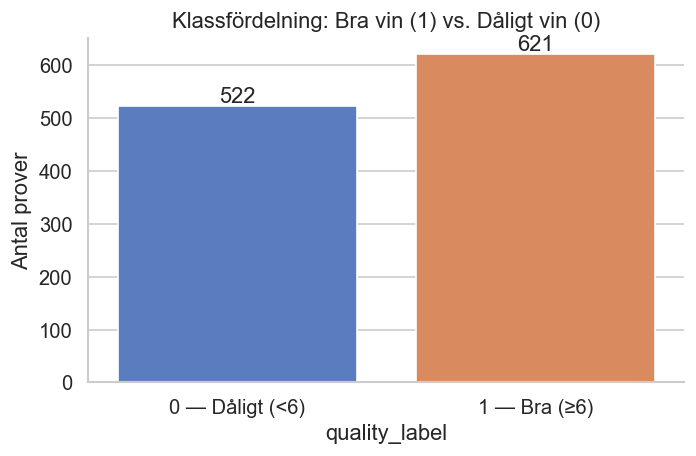

In [4]:
# ── Skapa binär label för EDA-syften ───────────────────────────────────────
df = df_raw.copy()
df["quality_label"] = (df["quality"] >= 6).astype(int)

# ── Räkna fördelning ────────────────────────────────────────────────────────
counts = df["quality_label"].value_counts().sort_index()
percentages = df["quality_label"].value_counts(normalize=True).sort_index() * 100

print("🔍 Klassfördelning (quality_label):")
for label, count in counts.items():
    pct = percentages[label]
    namn = "Bra vin (≥6)" if label == 1 else "Dåligt vin (<6)"
    print(f"   {label} — {namn}: {count} st ({pct:.1f}%)")

# ── Visualisering ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x="quality_label", hue="quality_label",
               palette="muted", legend=False, ax=ax)

ax.set_title("Klassfördelning: Bra vin (1) vs. Dåligt vin (0)")
ax.set_xlabel("quality_label")
ax.set_ylabel("Antal prover")
ax.set_xticks([0, 1])
ax.set_xticklabels(["0 — Dåligt (<6)", "1 — Bra (≥6)"])

# Lägg till antal ovanpå staplarna
for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "class_distribution.png"), dpi=120)
plt.show()

### ✅ Vad ser vi?

- **522 prover (45.7%)** klassas som "dåligt vin" (`quality < 6`)
- **621 prover (54.3%)** klassas som "bra vin" (`quality ≥ 6`)

Fördelningen är **i princip balanserad** — skillnaden är bara cirka 8.6
procentenheter. Det betyder att:

- En modell som bara gissar majoritetsklassen ("bra vin") skulle få ungefär
  **54.3% accuracy** — vårt baseline att slå.
- Vi behöver **inte** vidta särskilda åtgärder för klassobalans (t.ex.
  `class_weight`, oversampling/SMOTE) — vanlig binary crossentropy och
  standard train/val/test-split fungerar bra här.
- Metrics som **accuracy och AUC** kommer båda vara meningsfulla att tolka,
  eftersom ingen klass dominerar.

OBS: dessa siffror är beräknade på **rådata (1143 rader, inkl. dubbletter)**.
Efter att `load_data()` droppar dubbletterna kan fördelningen ändras marginellt
— det kollar vi i nästa notebook när pipelinen körs på riktigt.

➡️ Nästa steg: titta på hur varje numerisk feature är fördelad, och om
fördelningen skiljer sig mellan bra och dåligt vin.

## Cell 5 — Numeriska features: histogram uppdelat på target

Nu går vi igenom alla 11 kemiska features, en i taget, och tittar på:

- **Fördelningens form** — är den symmetrisk, skev, har den outliers?
- **Skillnad mellan klasserna** — flyttar sig fördelningen för "bra vin"
  jämfört med "dåligt vin"? Om ja, är detta en feature som troligen är
  **prediktiv**.

Vi använder `sns.histplot` med `hue="quality_label"` för att lägga de två
klassernas fördelningar ovanpå varandra i samma diagram — det gör det enkelt
att jämföra dem visuellt.

Vi loopar över alla 11 features och lägger dem i ett rutnät (grid) av subplots
så att vi får en överblick av hela datasetet i ett enda diagram.

🔍 Antal features: 11
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


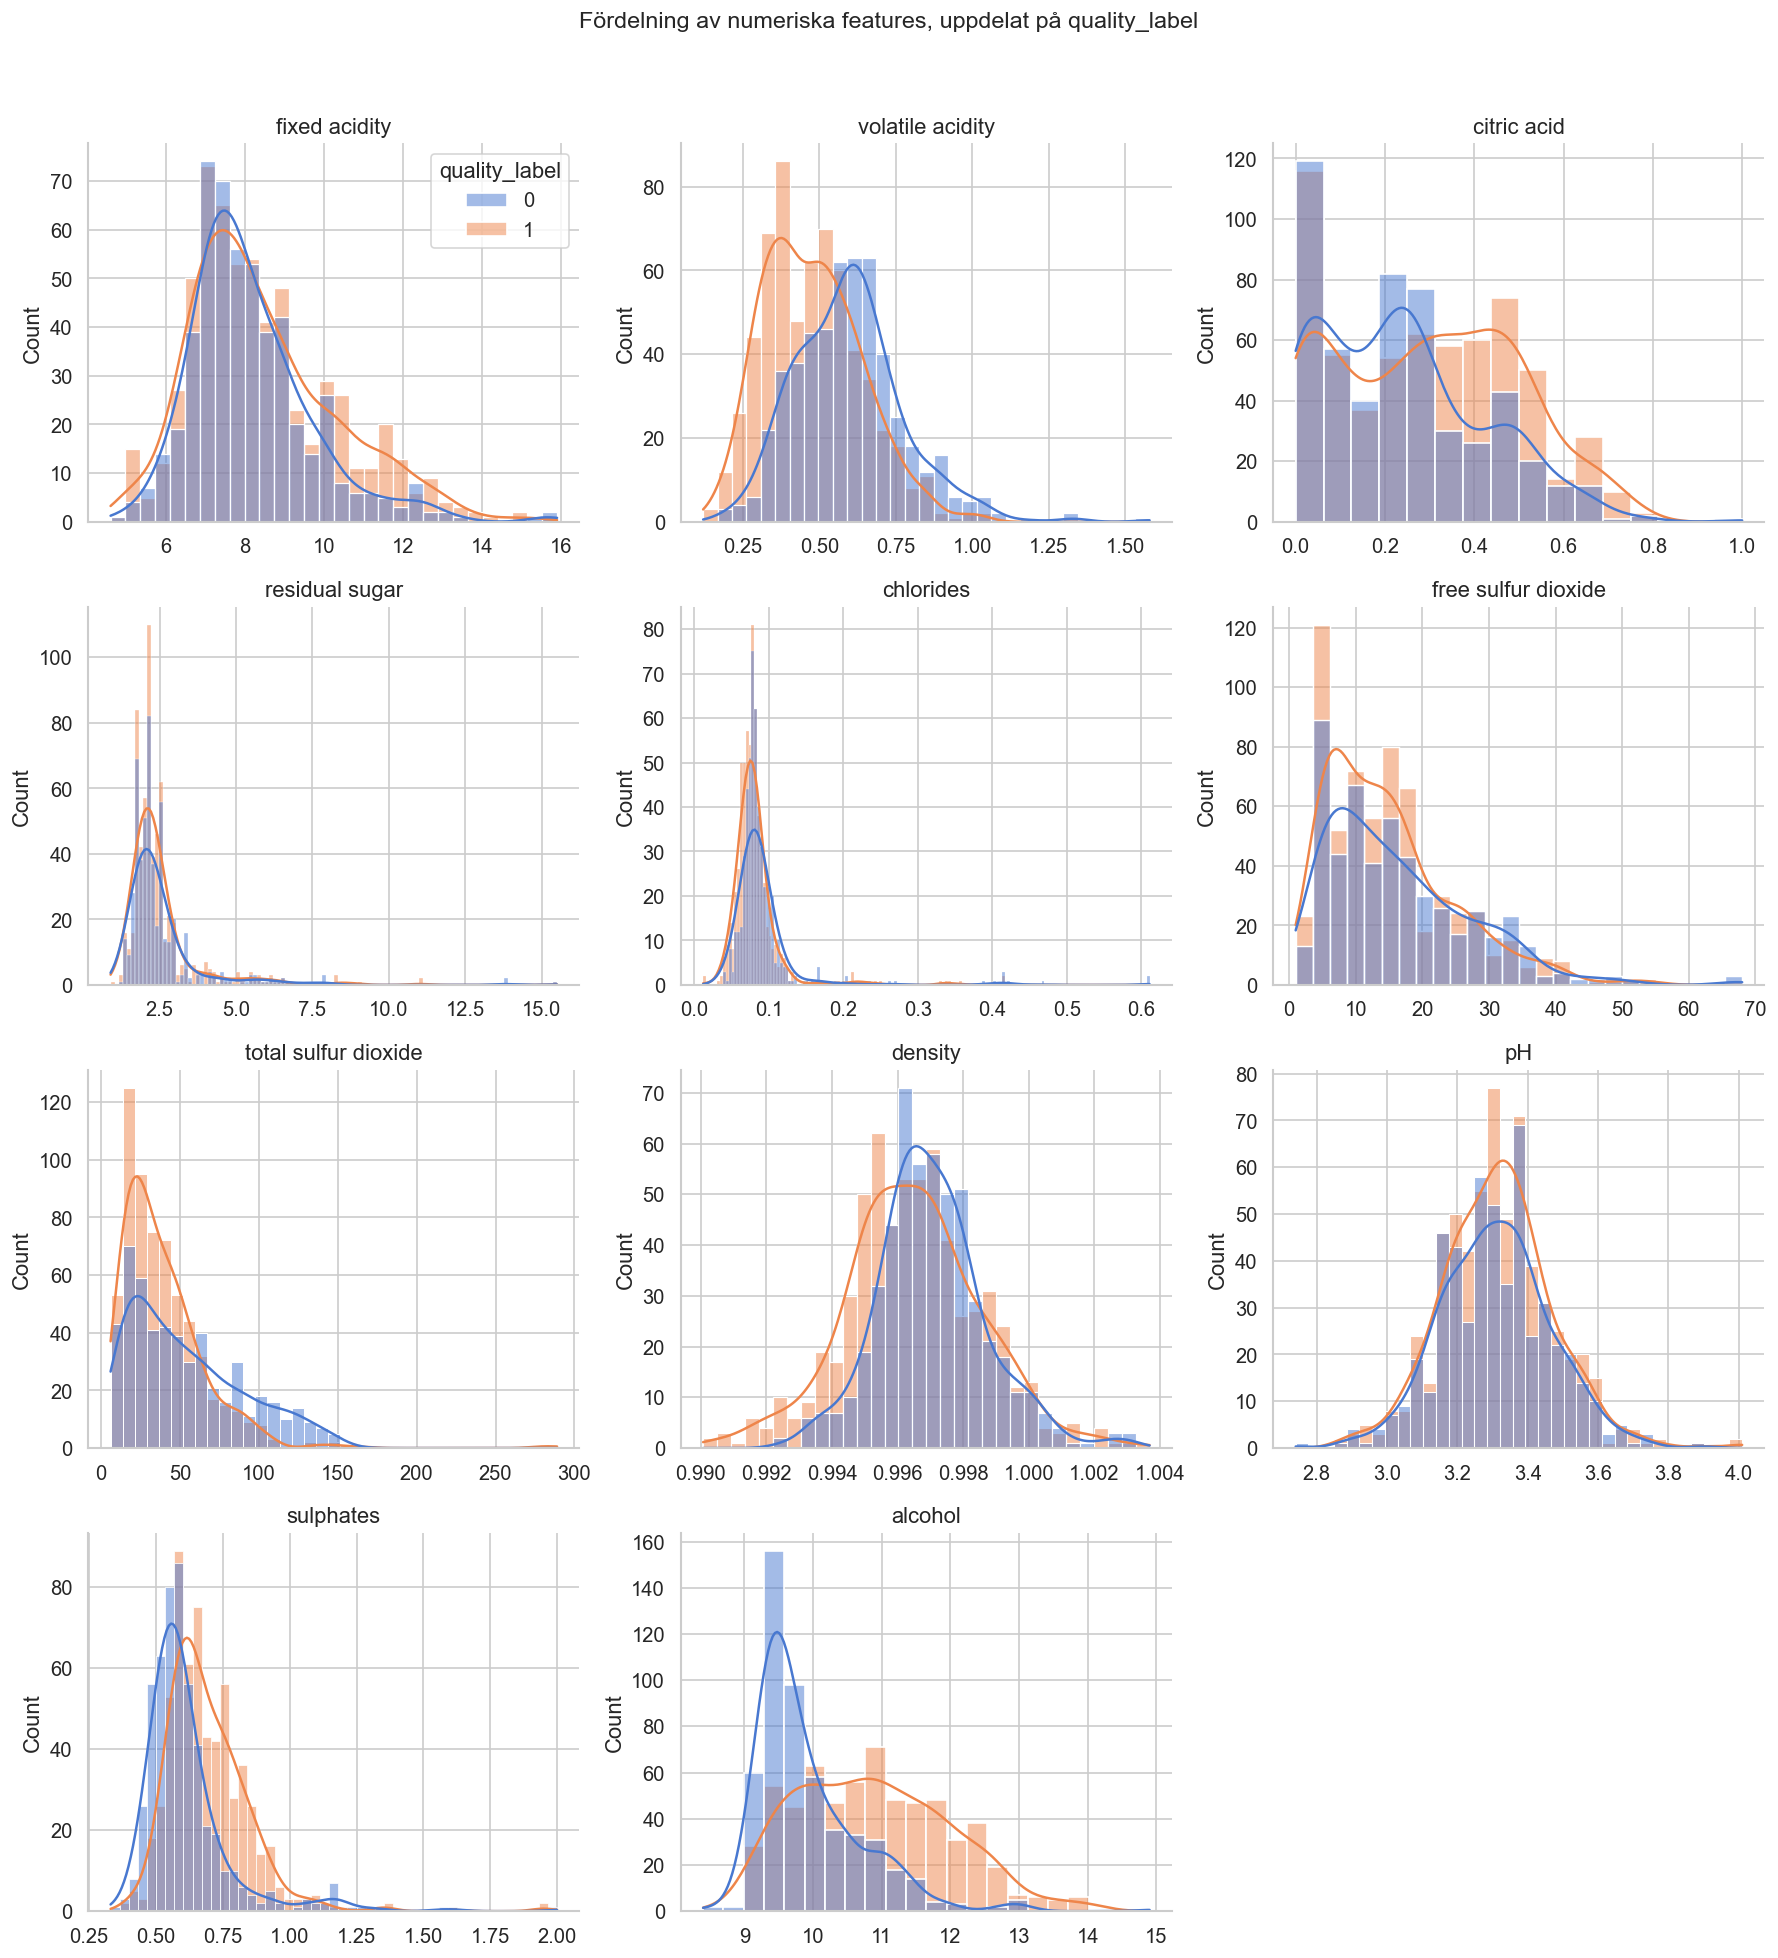

In [5]:
# ── Lista över alla numeriska features (exkl. quality, quality_label, Id) ──
FEATURES = [col for col in df.columns if col not in ["quality", "quality_label", "Id"]]
print(f"🔍 Antal features: {len(FEATURES)}")
print(FEATURES)

# ── Rutnät: 11 features → 3 kolumner x 4 rader (sista rutan blir tom) ──────
n_cols = 3
n_rows = int(np.ceil(len(FEATURES) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(FEATURES):
    sns.histplot(
        data=df, x=feature, hue="quality_label",
        kde=True, alpha=0.5, palette="muted",
        ax=axes[i], legend=(i == 0)        # visa legend bara på första plotten
    )
    axes[i].set_title(feature)
    axes[i].set_xlabel("")

# ── Dölj eventuella tomma subplots ─────────────────────────────────────────
for j in range(len(FEATURES), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Fördelning av numeriska features, uppdelat på quality_label", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "feature_histograms.png"), dpi=120, bbox_inches="tight")
plt.show()

### ✅ Vad ser vi?

Vi har 11 numeriska features. Flera av dem visar tydlig skillnad mellan
klasserna (0 = dåligt, 1 = bra), vilket gör dem potentiellt **prediktiva**:

| Feature | Observation |
|---|---|
| **alcohol** | Tydligast skillnad! Bra vin (orange) har en bredare fördelning förskjuten mot **högre alkoholhalt** (10–13%), medan dåligt vin (blått) klumpar sig kring 9–10%. |
| **volatile acidity** | Bra vin har lägre värden (toppar runt 0.35–0.4), dåligt vin sprider sig mer mot högre värden (0.6+). Hög flyktig syra ger vinet en "vinägertasvärden ut" — rimligt att det korrelerar med lägre kvalitet. |
| **density** | Bra vin har något lägre densitet, vilket hänger ihop med högre alkoholhalt (alkohol är lättare än vatten). |
| **sulphates** | Bra vin tenderar mot något högre värden (förskjutning mot 0.6–1.0). |
| **total sulfur dioxide** | Dåligt vin har en bredare, mer utdragen svans mot höga värden (100–300), bra vin är mer koncentrerat under 50. |
| **citric acid** | Bra vin har generellt något högre halter — möjligen kopplat till syrlighet/fräschör. |

Features som **fixed acidity, residual sugar, chlorides, free sulfur dioxide
och pH** visar mindre tydlig separation mellan klasserna — fördelningarna
överlappar i hög grad.

Flera fördelningar är **högerskeva** (residual sugar, chlorides, total sulfur
dioxide, free sulfur dioxide) med en lång svans av höga värden — detta är
typiskt för kemiska koncentrationer och bekräftar att **standardisering**
(StandardScaler i `preprocess()`) är ett bra val innan vi tränar ANN:et,
eftersom neurala nätverk är känsliga för skalskillnader mellan features.

➡️ Nästa steg: korrelationsmatrisen — bekräftar den dessa observationer, och
finns det features som korrelerar starkt med varandra (multikollinearitet)?

## Cell 6 — Korrelationsmatris

Histogrammen visade oss hur enskilda features fördelar sig mot target. Nu
tittar vi på **relationerna mellan alla features** samtidigt, med en
korrelationsmatris (heatmap).

Detta hjälper oss att svara på två frågor:

1. **Vilka features korrelerar mest med `quality_label`?** — dessa är troligen
   våra starkaste prediktorer.
2. **Korrelerar features starkt med varandra (multikollinearitet)?** — t.ex.
   är `density` och `alcohol` ofta starkt korrelerade fysikaliskt (mer alkohol
   → lägre densitet). Detta är inte ett stort problem för ANN på samma sätt
   som för linjär regression, men det är bra att känna till för tolkning.

Vi använder Pearsons korrelationskoefficient (`df.corr()`), som mäter
**linjära** samband mellan -1 och 1.

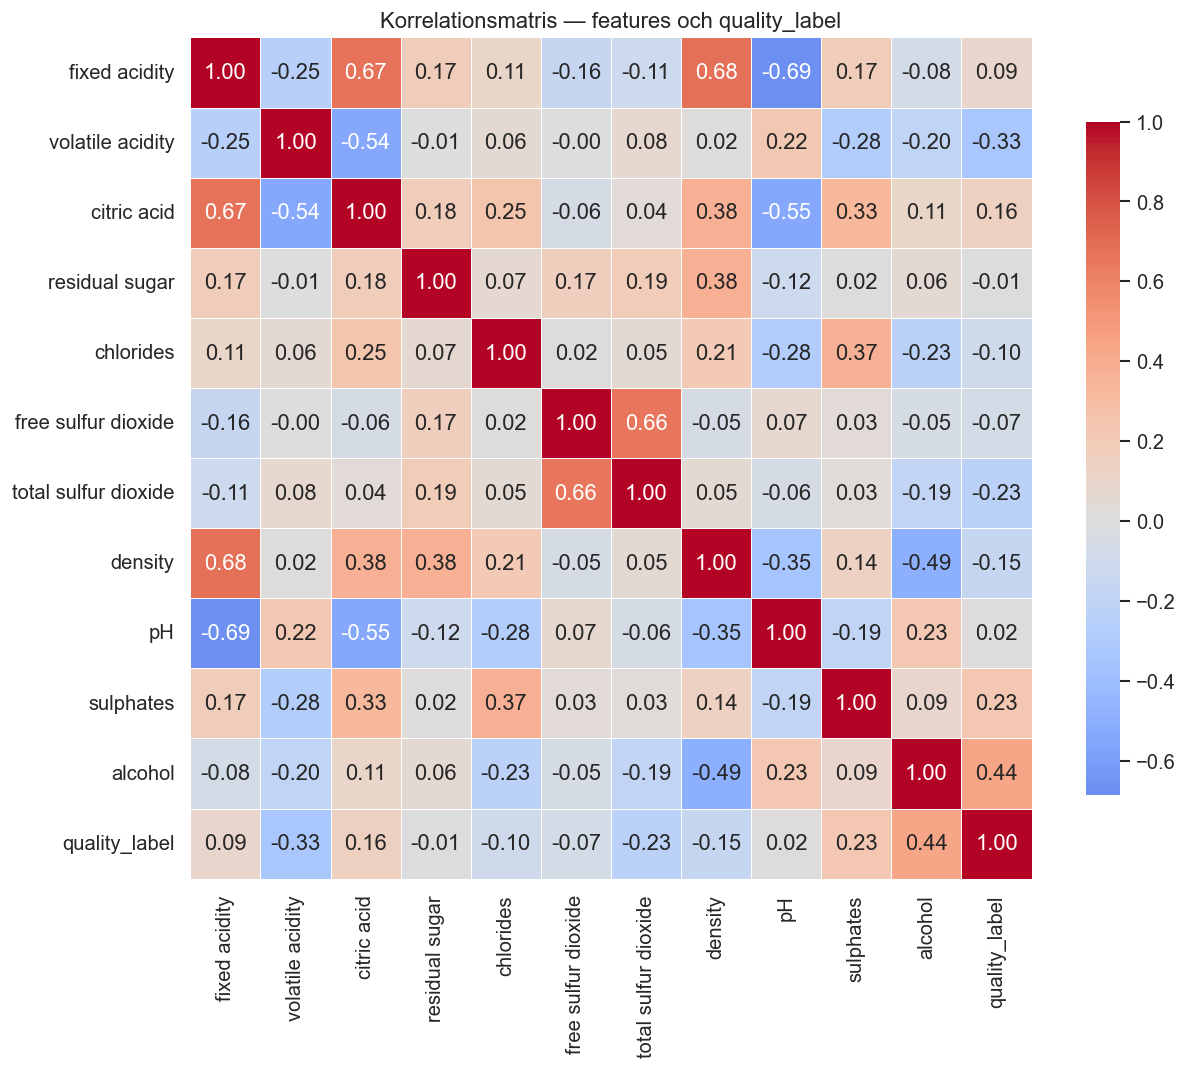

🔍 Korrelation med quality_label (starkast → svagast):
alcohol                 0.440397
volatile acidity       -0.330787
sulphates               0.234221
total sulfur dioxide   -0.226680
citric acid             0.155144
density                -0.154255
chlorides              -0.100601
fixed acidity           0.088682
free sulfur dioxide    -0.070577
pH                      0.015251
residual sugar         -0.007732
Name: quality_label, dtype: float64


In [6]:
# ── Beräkna korrelationsmatris (alla numeriska kolumner inkl. quality_label) ─
corr_cols = FEATURES + ["quality_label"]
corr_matrix = df[corr_cols].corr()

# ── Heatmap ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 9))

sns.heatmap(
    corr_matrix,
    annot=True, fmt=".2f",
    cmap="coolwarm", center=0,
    square=True, linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    ax=ax
)

ax.set_title("Korrelationsmatris — features och quality_label")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "correlation_matrix.png"), dpi=120, bbox_inches="tight")
plt.show()

# ── Visa de starkaste korrelationerna med target, sorterat ────────────────
target_corr = corr_matrix["quality_label"].drop("quality_label").sort_values(key=abs, ascending=False)
print("🔍 Korrelation med quality_label (starkast → svagast):")
print(target_corr)

### ✅ Vad ser vi?

**Korrelation med `quality_label`** bekräftar mönstren från histogrammen:

| Feature | Korrelation | Tolkning |
|---|---|---|
| **alcohol** | **+0.44** | Starkast korrelation totalt. Högre alkoholhalt → högre sannolikhet för "bra vin". |
| **volatile acidity** | **−0.33** | Näst starkast. Högre flyktig syra → "vinägerton" → lägre kvalitet. |
| **sulphates** | +0.23 | Svagt positiv — högre sulfatnivå hänger ihop med bättre kvalitet. |
| **total sulfur dioxide** | −0.23 | Svagt negativ — mer SO₂ totalt → något lägre kvalitet. |
| **citric acid** | +0.16 | Svag positiv koppling. |
| Övriga (density, chlorides, fixed acidity, free SO₂, pH, residual sugar) | \|r\| < 0.16 | Mycket svag enskild linjär koppling till target. |

**Multikollinearitet — features som korrelerar starkt med varandra:**

- **`fixed acidity` ↔ `citric acid` (0.67)** och **`fixed acidity` ↔ `density` (0.68)** —
  rimligt, mer syra/fasta ämnen ökar densiteten.
- **`fixed acidity` ↔ `pH` (−0.69)** och **`citric acid` ↔ `pH` (−0.55)** —
  pH är ett mått på syrahalt, så detta är väntat (lägre pH = surare).
- **`free sulfur dioxide` ↔ `total sulfur dioxide` (0.66)** — fritt SO₂ är en
  delmängd av totalt SO₂, så ett samband är naturligt.
- **`density` ↔ `alcohol` (−0.49)** — som väntat: mer alkohol sänker densiteten.

**Vad betyder detta för modelleringen?**

- Ingen enskild feature har extremt hög korrelation (>0.5) med target — vi
  behöver troligen **kombinationer** av features för att fånga mönstret, vilket
  är precis vad ett ANN med dolda lager är bra på (icke-linjära samband).
- Multikollinearitet mellan features (t.ex. fixed acidity/citric acid/pH/density)
  är **inget akut problem för ANN** (till skillnad från t.ex. linjär regression),
  men förklarar varför vissa features kan verka "redundanta".
- `alcohol` och `volatile acidity` är de features vi förväntar oss att modellen
  lär sig vikta tyngst.

➡️ Nästa steg: boxplots — visualisera `alcohol` och `volatile acidity` (samt
några till) direkt mot `quality_label` för att se separationen tydligare.

## Cell 7 — Features vs target: boxplots

Histogrammen och korrelationsmatrisen pekade ut **alcohol**, **volatile
acidity**, **sulphates**, **total sulfur dioxide**, **citric acid** och
**density** som de mest intressanta features. Nu zoomar vi in på dessa med
boxplots, uppdelade per `quality_label`.

**Varför boxplot?** En boxplot visar median, kvartiler (IQR) och outliers i
ett kompakt format — perfekt för att snabbt jämföra **var "mitten" av
fördelningen ligger** för klass 0 vs. klass 1. Om lådorna ligger tydligt
förskjutna mot varandra (liten överlappning) är featuren en stark separator.

Vi väljer ut de 6 features med starkast (absolut) korrelation med target och
plottar dem i ett 2×3-rutnät.

🔍 Topp 6 features (efter |korrelation| med quality_label):
['alcohol', 'volatile acidity', 'sulphates', 'total sulfur dioxide', 'citric acid', 'density']


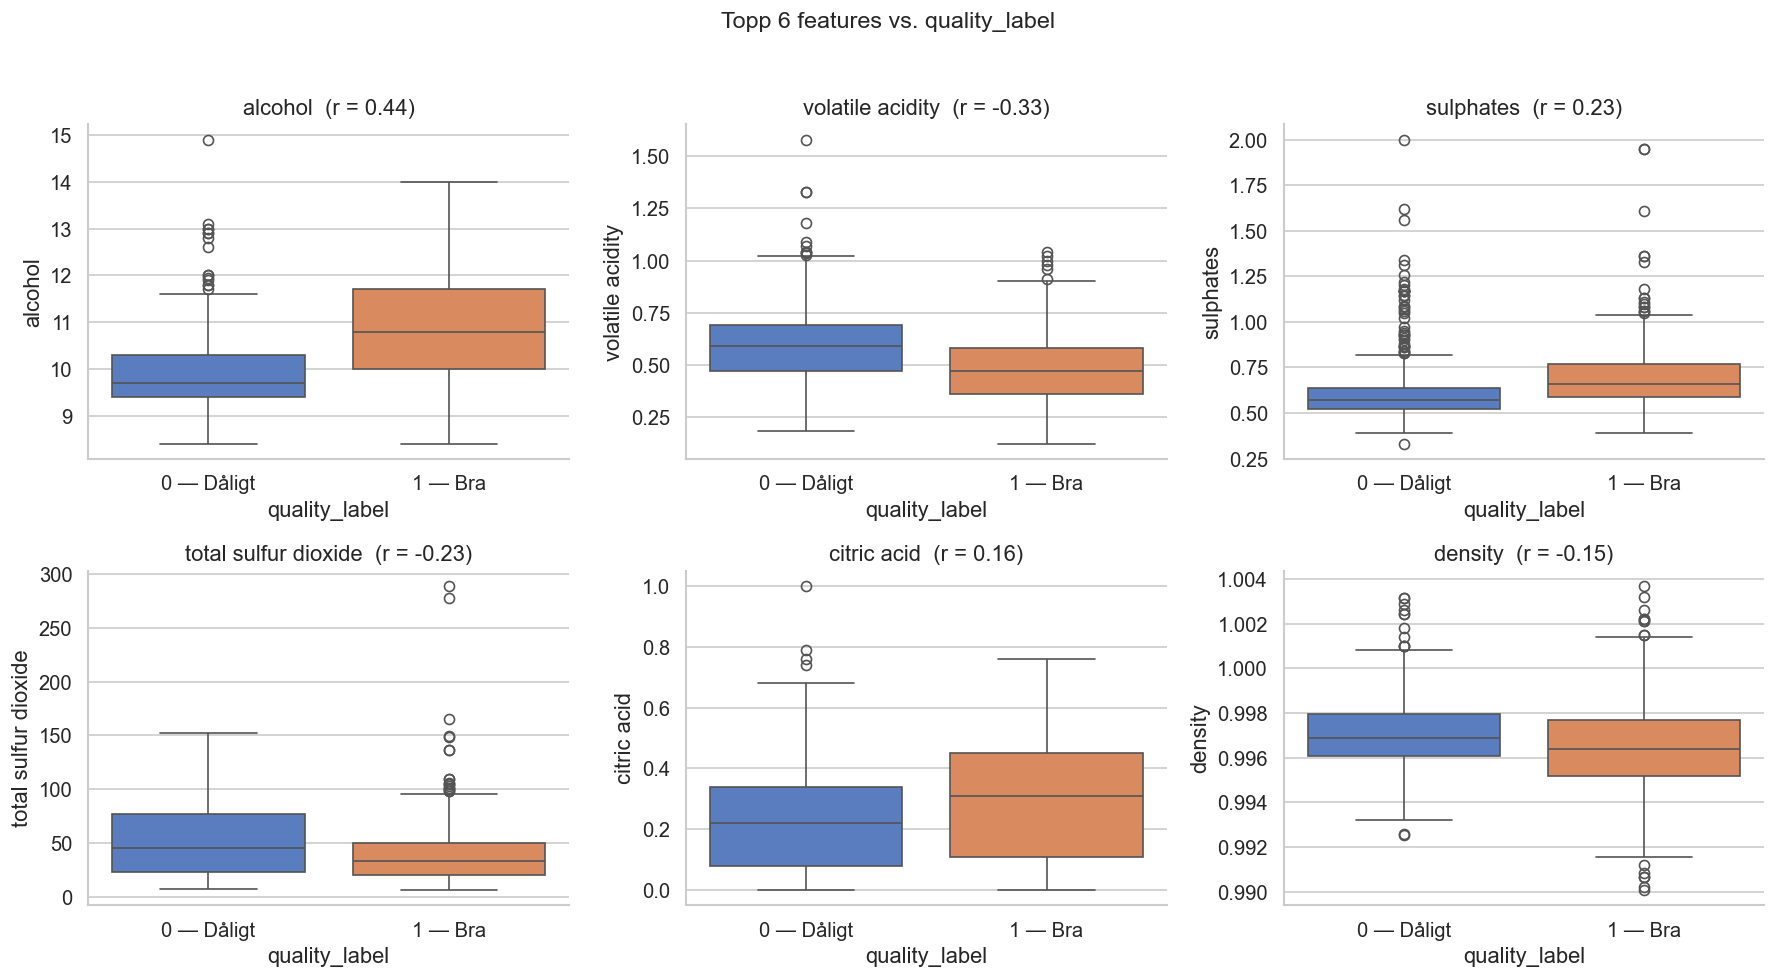

In [7]:
# ── Topp 6 features efter |korrelation| med quality_label ─────────────────
TOP_FEATURES = target_corr.abs().sort_values(ascending=False).head(6).index.tolist()
print(f"🔍 Topp 6 features (efter |korrelation| med quality_label):")
print(TOP_FEATURES)

# ── Boxplots i 2x3-rutnät ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(TOP_FEATURES):
    sns.boxplot(
        data=df, x="quality_label", y=feature,
        hue="quality_label", palette="muted", legend=False,
        ax=axes[i]
    )
    corr_val = target_corr[feature]
    axes[i].set_title(f"{feature}  (r = {corr_val:.2f})")
    axes[i].set_xlabel("quality_label")
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["0 — Dåligt", "1 — Bra"])

fig.suptitle("Topp 6 features vs. quality_label", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "top_features_boxplots.png"), dpi=120, bbox_inches="tight")
plt.show()

### ✅ Vad ser vi?

Boxplotsen bekräftar och förtydligar bilden från korrelationsmatrisen:

- **alcohol (r = 0.44):** Tydligast separation av alla. Medianen för "bra vin"
  ligger nästan en hel enhet högre (~10.8% vs. ~9.7%), och de övre 75%-kvartilen
  för bra vin nästan motsvarar undre kvartilen för dåligt vin. Detta är vår
  starkaste enskilda prediktor.
- **volatile acidity (r = −0.33):** Tydlig förskjutning åt motsatt håll —
  "dåligt vin" har en högre median och bredare övre del av lådan. Många outliers
  i klass 0 mot höga värden (>1.0).
- **sulphates (r = 0.23):** Måttlig men synlig förskjutning — bra vin har
  något högre median och hela lådan förskjuten uppåt.
- **total sulfur dioxide (r = −0.23):** Dåligt vin har högre median och bredare
  spridning, men klass 1 har några extrema outliers (>250) som drar ner
  korrelationen.
- **citric acid (r = 0.16):** Svagare separation, men bra vin tenderar mot
  högre värden och en bredare övre del av lådan.
- **density (r = −0.15):** Svagast av de sex — lådorna överlappar mycket, men
  dåligt vin ligger marginellt högre, konsekvent med dess koppling till lägre
  alkoholhalt.

**Genomgående mönster:** Många features har ett stort antal **outliers** (de
små cirklarna ovanför/under "morrhåren"), särskilt `sulphates`, `total sulfur
dioxide` och `density`. Detta är typiskt för kemiska mätningar och förstärker
behovet av **standardisering** snarare än att ta bort outliers — ett ANN med
Dropout och L2-regularisering (som vi redan har i `model.py`) hanterar denna
typ av brus relativt robust.

➡️ Nästa steg: sammanfatta alla fynd från EDA i en avslutande markdown-cell —
detta blir vår "facit" inför modellbygget och presentationen.

## Cell 8 — Sammanfattning av fynd

### 📊 Datasetet

- **1143 rader, 13 kolumner** i rådata. Efter att dubbletter (exkl. `Id`)
  droppas i `load_data()`: **1018 unika prover**.
- **0 saknade värden** — datasetet är komplett, ingen imputering krävs.
- **125 dubbletter** (exkl. `Id`) — viktigt att droppa innan train/val/test-split
  för att undvika data leakage.

### 🎯 Target — `quality_label`

- Binär target skapad genom `quality ≥ 6 → 1` (bra), `quality < 6 → 0` (dåligt).
- Fördelning på rådata: **45.7% dåligt (0) / 54.3% bra (1)** — i princip
  balanserad. Ingen särskild hantering av klassobalans behövs.
- Baseline att slå: **~54.3% accuracy** (gissa majoritetsklassen).

### 🔍 Viktigaste features

| Feature | Korrelation med target | Tolkning |
|---|---|---|
| **alcohol** | +0.44 | Starkast prediktor — högre alkoholhalt → bättre kvalitet |
| **volatile acidity** | −0.33 | Näst starkast — hög flyktig syra → sämre kvalitet |
| **sulphates** | +0.23 | Måttlig positiv koppling |
| **total sulfur dioxide** | −0.23 | Måttlig negativ koppling |
| **citric acid** | +0.16 | Svag positiv koppling |
| **density** | −0.15 | Svag negativ koppling (hänger ihop med alkohol) |

Övriga features (`fixed acidity`, `residual sugar`, `chlorides`, `free sulfur
dioxide`, `pH`) har svag enskild linjär korrelation (\|r\| < 0.11) med target,
men kan fortfarande bidra i kombination med andra features — vilket ett ANN
är designat för att fånga upp.

### ⚠️ Multikollinearitet (mellan features, inte ett akut problem för ANN)

- `fixed acidity` ↔ `citric acid` (0.67), `fixed acidity` ↔ `density` (0.68),
  `fixed acidity` ↔ `pH` (−0.69), `citric acid` ↔ `pH` (−0.55) — alla kopplade
  till syrahalt/pH-kemi.
- `free sulfur dioxide` ↔ `total sulfur dioxide` (0.66) — fritt SO₂ är en
  delmängd av totalt SO₂.
- `density` ↔ `alcohol` (−0.49) — mer alkohol sänker densiteten.

### 📐 Implikationer för modellering

1. **Standardisering är nödvändigt** — features har mycket olika skalor (t.ex.
   `total sulfur dioxide` 0–300 vs. `citric acid` 0–1) och flera är skeva med
   outliers. `StandardScaler` i `preprocess()` hanterar detta.
2. **Dropp av dubbletter** (görs i `load_data()`) är kritiskt för att undvika
   data leakage mellan train/val/test.
3. **Ingen åtgärd för klassobalans behövs** — fördelningen är ~46/54.
4. **Ett ANN med dolda lager är motiverat** snarare än en enkel linjär modell:
   inga enskilda features har stark linjär korrelation (>0.5) med target, vilket
   tyder på att **icke-linjära kombinationer** av features (t.ex. alkohol +
   volatile acidity + sulphates tillsammans) krävs för att separera klasserna väl.
5. **Dropout + L2-regularisering** (redan i `model.py`) är lämpligt givet
   datasetets begränsade storlek (~1018 unika rader efter dedup) och risken
   för overfitting.

### 🍷 Att ta med till presentationen (data story)

- "Vad gör ett vin bra?" → **Högre alkoholhalt + lägre flyktig syra +** högre
  sulfatnivå är de starkaste indikatorerna i datat.
- För en producent: detta antyder att **jäsningsprocess** (alkoholhalt) och
  **kvalitetskontroll av flyktig syra** (kopplat till bakteriell kontaminering/
  ättiksyrabildning) är de mest värdefulla parametrarna att övervaka och
  optimera för att höja den upplevda vinkvaliteten.

---